In [6]:
%cd /Users/amarmesic/Documents/tudelft/thesis/DNANet

/Users/amarmesic/Documents/tudelft/thesis/DNANet


/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [7]:
from DNAnet.data.data_models.hid_image import HIDImage
from DNAnet.data.data_models.dna_models import Panel

from DNAnet.data.parsing import get_peak_data
from DNAnet.evaluation.visualizations import plot_profile
from DNAnet.data.data_models.dna_models import Annotation
from DNAnet.evaluation.visualizations import plot_profile_markers
from DNAnet.data.data_models.synthetic_image import SyntheticImage


import matplotlib.pyplot as plt
import numpy as np

# Create Synthetic Image

In [ ]:
base_dir = "/Users/amarmesic/Documents/tudelft/thesis/dna/generated_epgs/fixed_ratios_base_template_500_5000_scaled_uniform_z-BEST"
dataset_files_dir = f"{base_dir}/epgs/epg_configID1_sample_0001_N2_250_250_bb_rep1_deg1.npy"
reference_genotype_path = f"{base_dir}/reference_genotypes"
epg_to_genotypes_mapping_path = f"{base_dir}/alleles_to_genotypes_mapping.csv"
gf_panel_path = "resources/data/ProvedIt/SGPanel_Globalfiler_Panel.xml"

image = SyntheticImage(
    path=dataset_files_dir,
    panel=Panel(gf_panel_path),
    reference_genotype_path=reference_genotype_path,
    epg_to_genotypes_mapping_path=epg_to_genotypes_mapping_path,
    size_standard="SYNTHETIC_GENESCAN_600_LIZ",
)

In [9]:
from config_io import load_model

unet_model = load_model("config/models/unet.yaml")
unet_model.load("resources/model/current_best_unet/")
predictions = unet_model.predict_batch([image])

2025-07-10 20:16:45 WARNING  Could not load true alleles for resources/data/synthetic/fixed_ratios_base_template_500_5000_no_preprocess/epgs/epg_configID1_sample_0001_N2_250_250_bb_rep1_deg1.npy: No contributors found for file epg_configID1_sample_0001_N2_250_250_bb_rep1_deg1.npy in mapping.
2025-07-10 20:16:53 INFO     Calling alleles from predicted segmentation...


AttributeError: 'SyntheticImage' object has no attribute '_annotation'

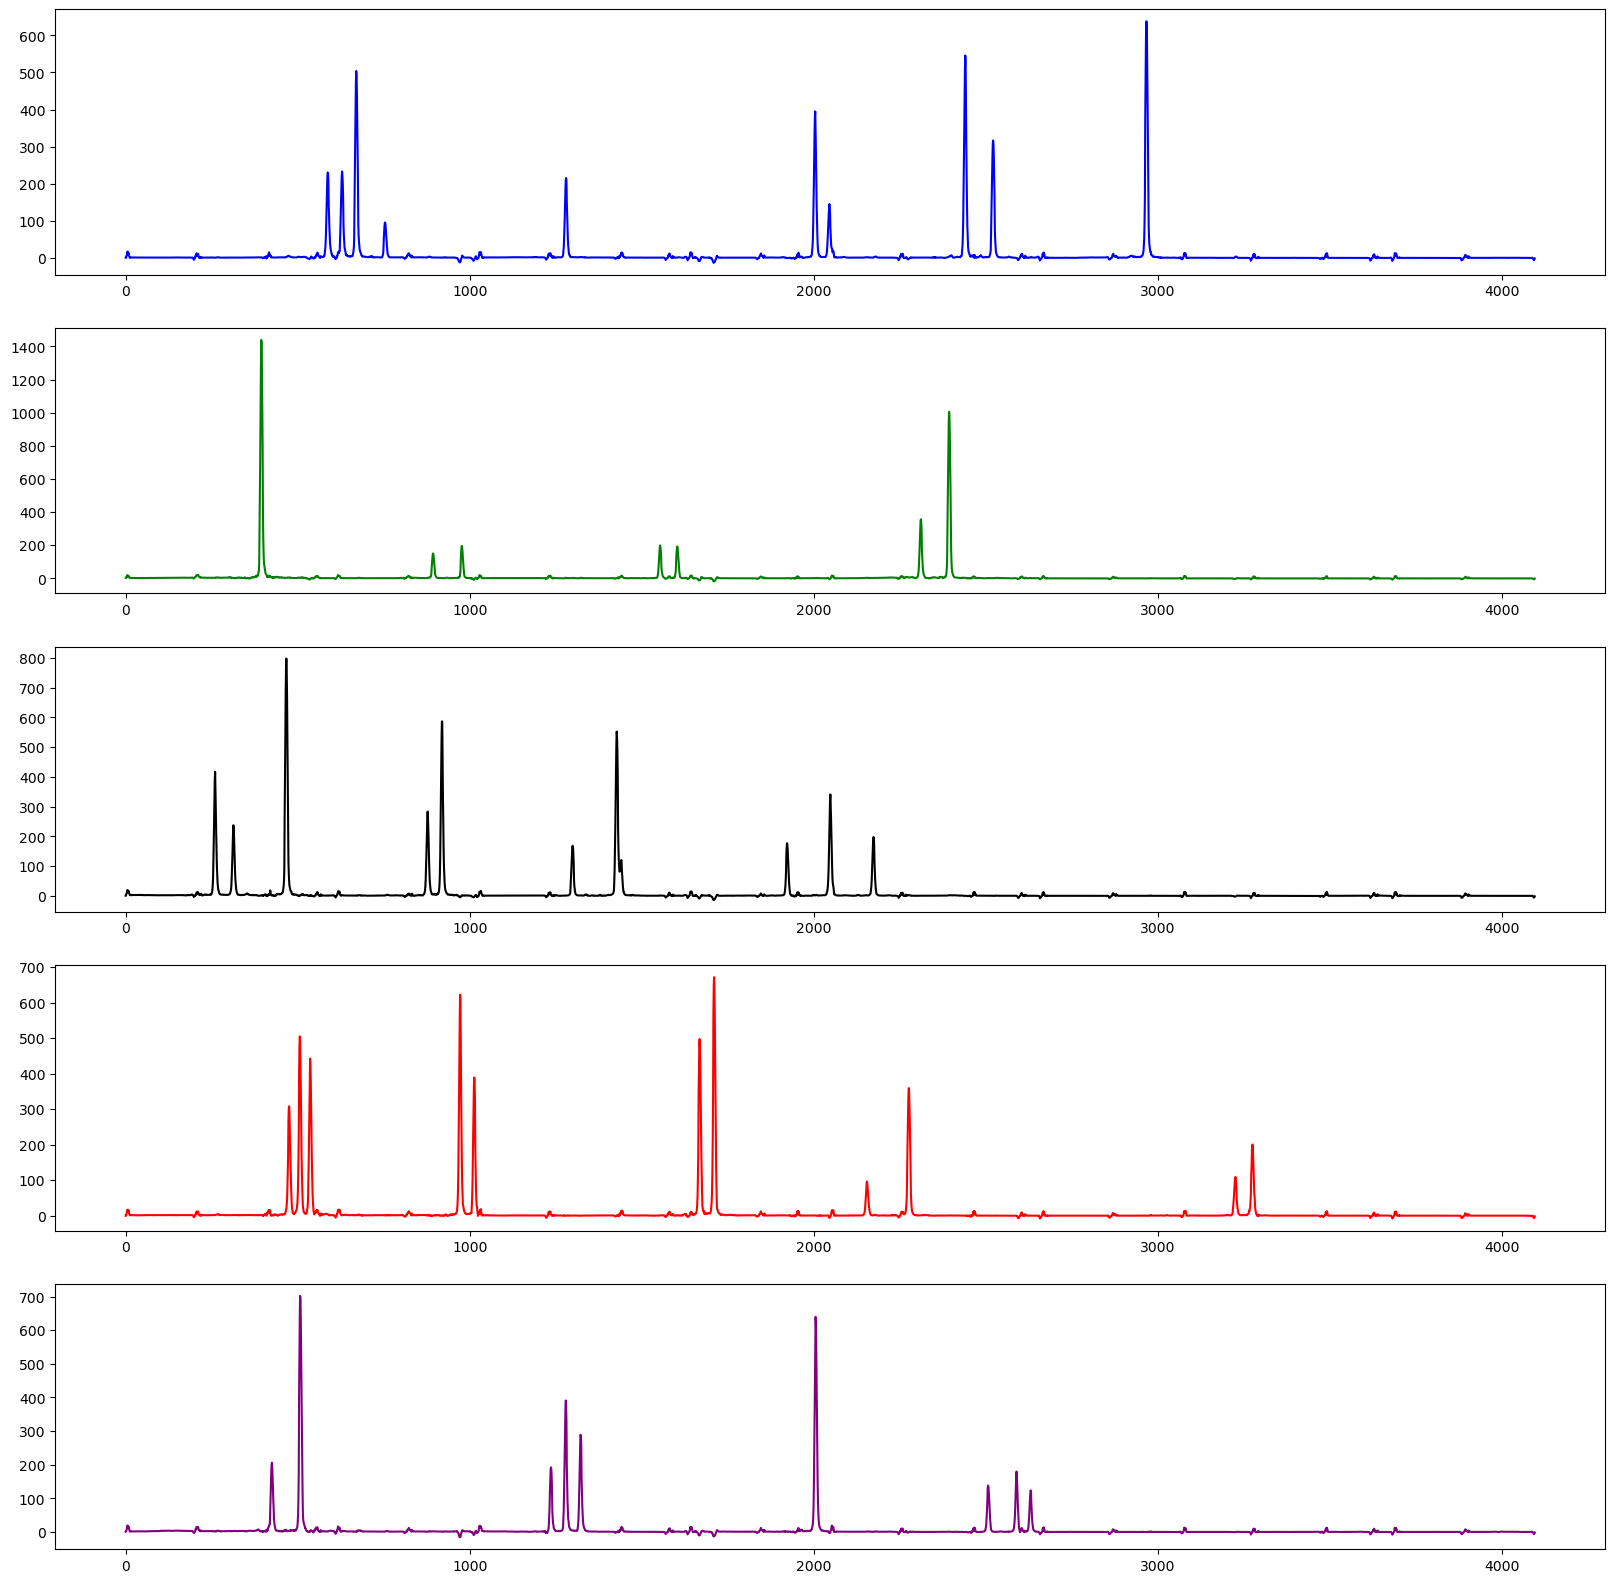

In [10]:
plot_profile([image], predictions, prediction_as_mask=False)

In [ ]:
predictions[0]

Prediction(classification=None, image=[[[2.21989012e-07]
  [3.38652939e-07]
  [2.68944314e-06]
  ...
  [8.69344058e-06]
  [1.50902861e-05]
  [1.15459365e-07]]

 [[1.43895420e-06]
  [5.23966378e-07]
  [7.07656511e-07]
  ...
  [2.59387707e-06]
  [3.84692294e-06]
  [8.90611716e-07]]

 [[2.72283523e-06]
  [2.04903063e-06]
  [7.60468254e-07]
  ...
  [8.29980706e-07]
  [7.46937474e-07]
  [8.54714074e-07]]

 [[4.22426729e-06]
  [6.91162143e-07]
  [1.03429670e-06]
  ...
  [6.68805887e-06]
  [1.13630244e-06]
  [7.94004450e-07]]

 [[2.13859789e-06]
  [1.91320282e-06]
  [1.90044807e-06]
  ...
  [3.77490978e-05]
  [2.25206622e-06]
  [1.27596570e-06]]], meta={'original_image_path': PosixPath('resources/data/synthetic/fixed_ratios_base_template_500_5000_no_preprocess/epgs/epg_configID1_sample_0001_N2_250_250_bb_rep1_deg1.npy'), 'called_alleles': [Marker(dye_row=0, name='D3S1358', alleles=[Allele(name='15', base_pair=None, left_bin=None, right_bin=None, height=232), Allele(name='14', base_pair=None, 

In [ ]:
from DNAnet.evaluation.segmentation.allele_metrics import allele_f1_score, allele_precision, allele_recall

hid_dataset = [image]

print('allele u-net f1: ', allele_f1_score(hid_dataset, predictions))
print('allele u-net precision: ', allele_precision(hid_dataset, predictions))
print('allele u-net recall: ', allele_recall(hid_dataset, predictions))

allele u-net f1:  0.7924528301886792
allele u-net precision:  0.9333333333333333
allele u-net recall:  0.6885245901639344
